### Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 20

In [3]:
df = pd.read_csv('D:\Personal Projects\Telco Churn\Merged_Data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 55 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Gender                             7043 non-null   object 
 3   Age                                7043 non-null   int64  
 4   Under 30                           7043 non-null   object 
 5   Senior Citizen                     7043 non-null   object 
 6   Married                            7043 non-null   object 
 7   Dependents                         7043 non-null   object 
 8   Number of Dependents               7043 non-null   int64  
 9   Location ID                        7043 non-null   object 
 10  Country                            7043 non-null   object 
 11  State                              7043 non-null   objec

### EDA

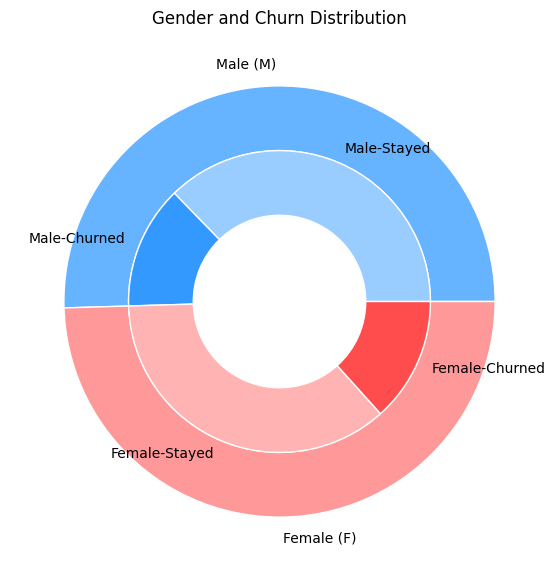

In [5]:
# overall gender totals
gender_counts = df['Gender'].value_counts()

# churn / stay counts by gender
gc = df.groupby(['Gender','Churn Value']).size().unstack(fill_value=0)
# gc.loc['Male',1] is churned males etc.

# prepare sizes for the two rings
outer_sizes = gender_counts.values
inner_sizes = [
    gc.loc['Male',0], gc.loc['Male',1],       # male stay, male churn
    gc.loc['Female',0], gc.loc['Female',1]    # female stay, female churn
]

# colors
outer_colors = ['#66b3ff','#ff9999']
inner_colors = ['#99ccff','#3399ff','#ffb3b3','#ff4d4d']

fig, ax = plt.subplots(figsize=(7,7))

# outer ring – gender distribution
ax.pie(
    outer_sizes,
    radius=1.0,
    labels=['Male (M)','Female (F)'],
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# inner ring – churn/stay by gender
ax.pie(
    inner_sizes,
    radius=0.7,
    labels=['Male‑Stayed','Male‑Churned','Female‑Stayed','Female‑Churned'],
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

ax.set(aspect="equal", title='Gender and Churn Distribution')
plt.show()

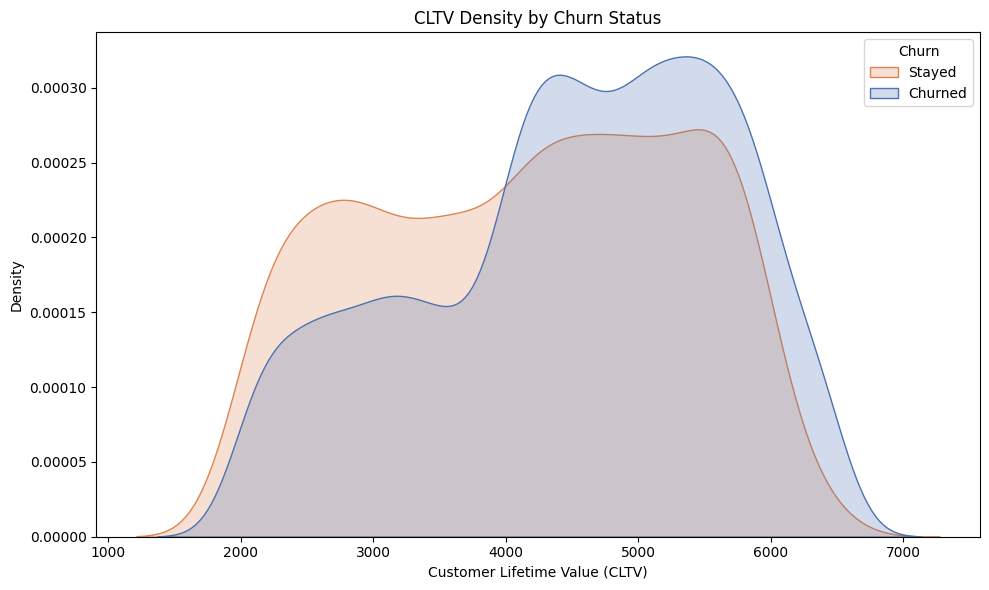

In [6]:
# density plot of CLTV by churn status
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x='CLTV',
    hue='Churn Value',
    fill=True,
    common_norm=False,
    palette=['#4C72B0','#DD8452']
)
plt.title('CLTV Density by Churn Status')
plt.xlabel('Customer Lifetime Value (CLTV)')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['Stayed','Churned'])
plt.tight_layout()
plt.show()

C:\Users\tangc\AppData\Local\Temp\ipykernel_20592\1987607466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Value', y='Tenure in Months', data=df,


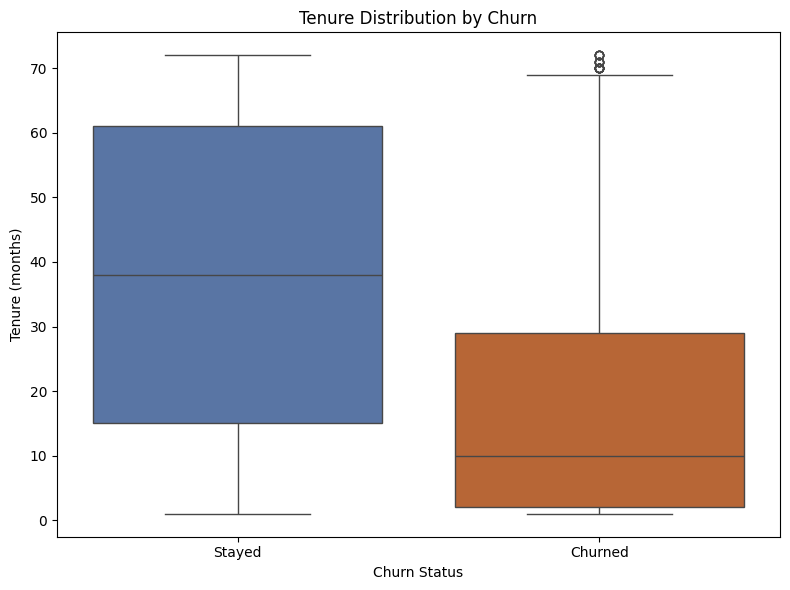

In [7]:
# boxplot of tenure by churn status
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn Value', y='Tenure in Months', data=df,
            palette=['#4C72B0', "#CD6020"])
plt.xticks([0,1], ['Stayed','Churned'])
plt.xlabel('Churn Status')
plt.ylabel('Tenure (months)')
plt.title('Tenure Distribution by Churn')
plt.tight_layout()
plt.show()

# Low tenure months associated with higher churn possibility. Outliers appear in churned group.

In [8]:
# drop unnecessary columns
cols_to_drop = [
    'Customer ID', 'Count', 'Under 30', 'Senior Citizen', 'Dependents', 'Location ID', 'Country',
    'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Service ID',
    'Total Extra Data Charges', 'Quarter', 'Referred a Friend', 'Phone Service', 'Internet Service',
    'Status ID', 'Customer Status', 'Churn Label', 'Churn Category', 'Churn Reason',
    'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Total Refunds',
    'Gender', 'Married', 'Total Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn Score'
]

df = df.drop(columns=cols_to_drop)

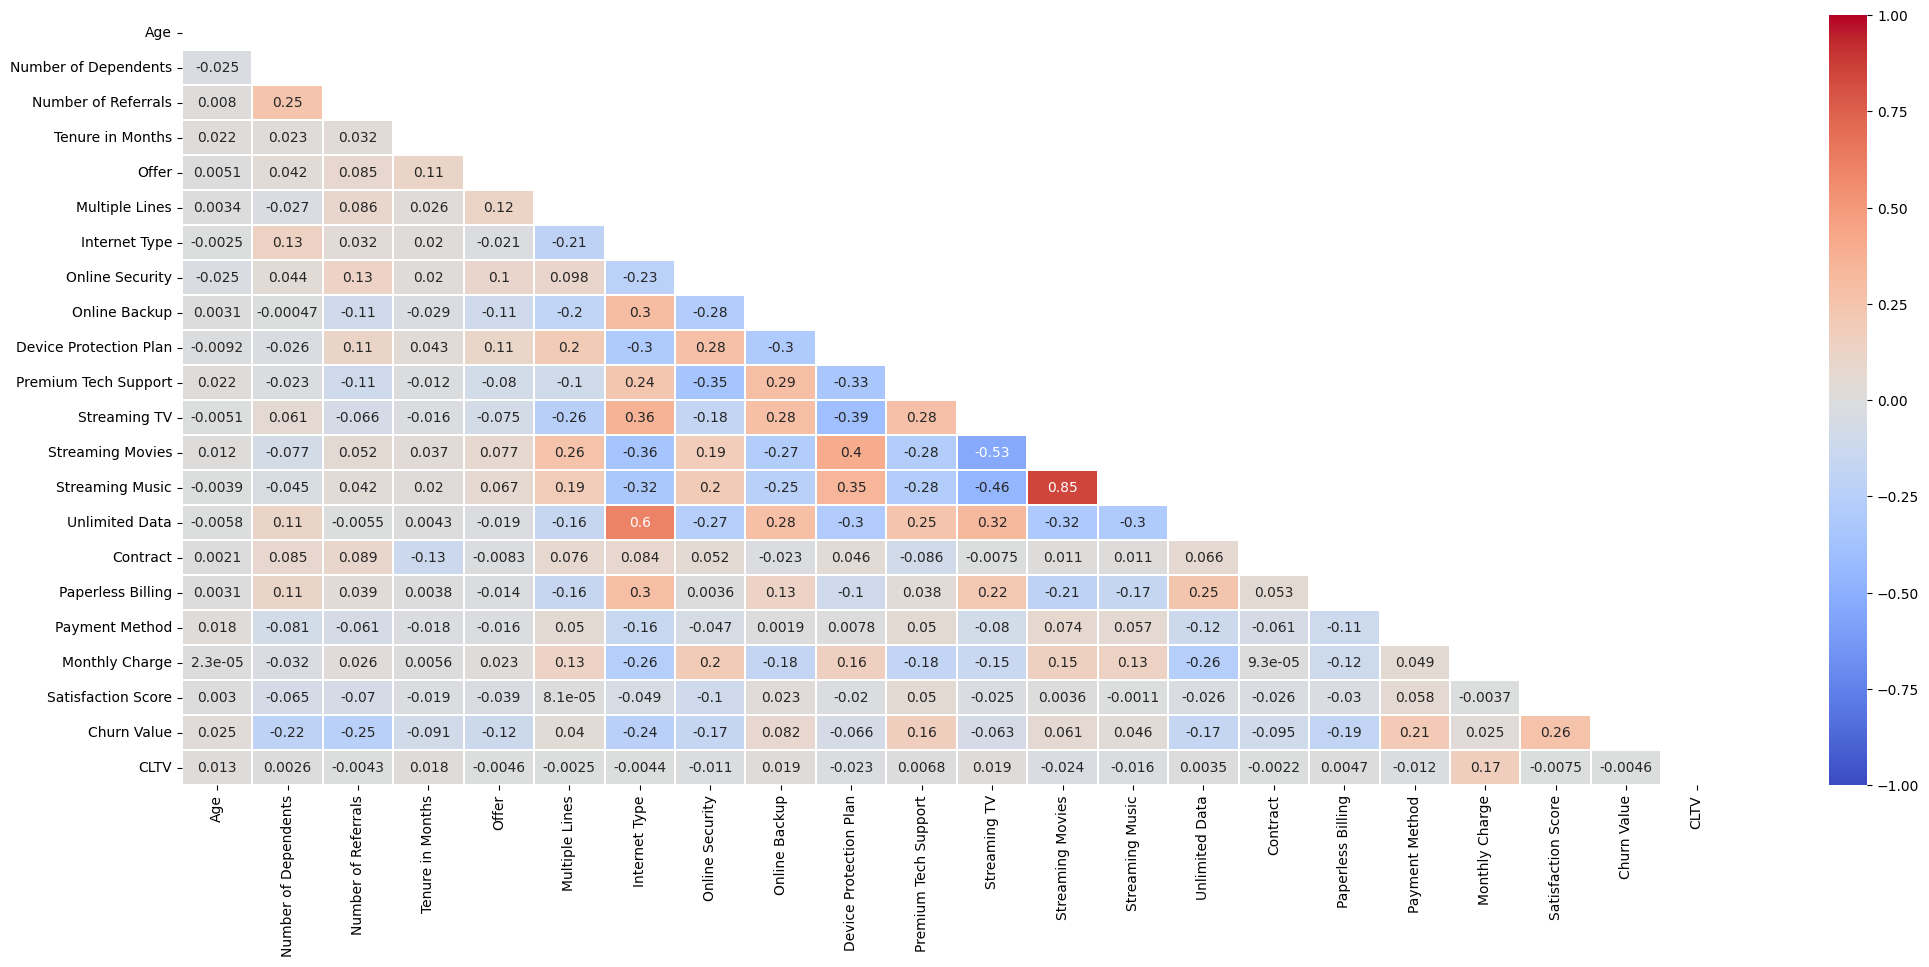

In [9]:
# correlation heatmap
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

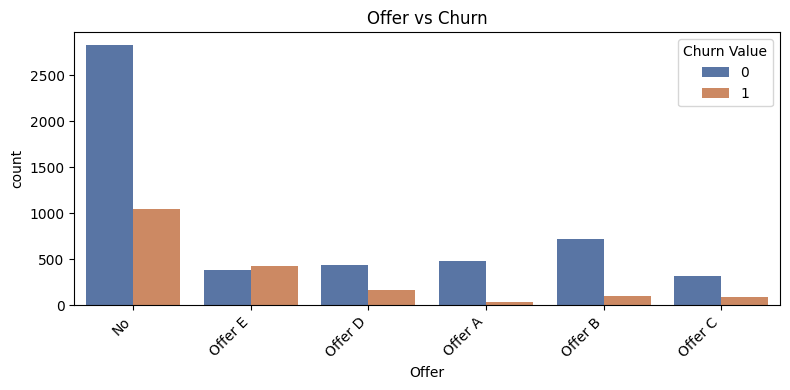

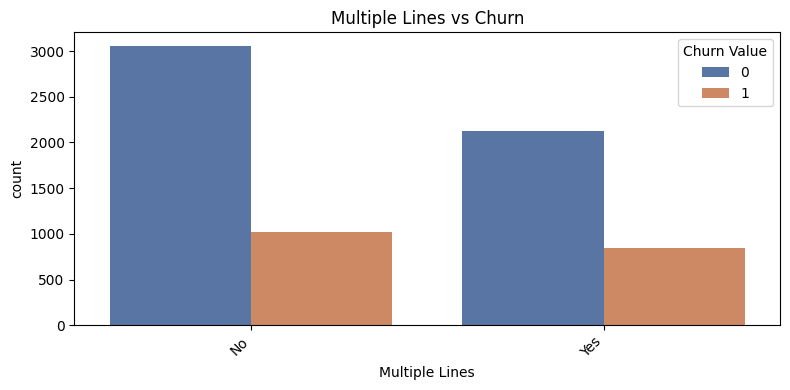

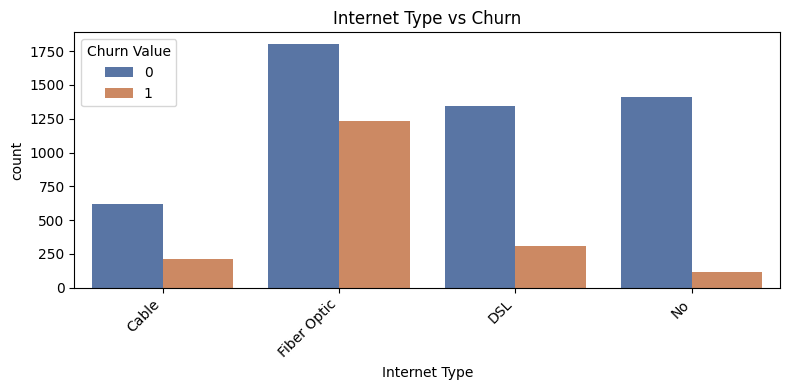

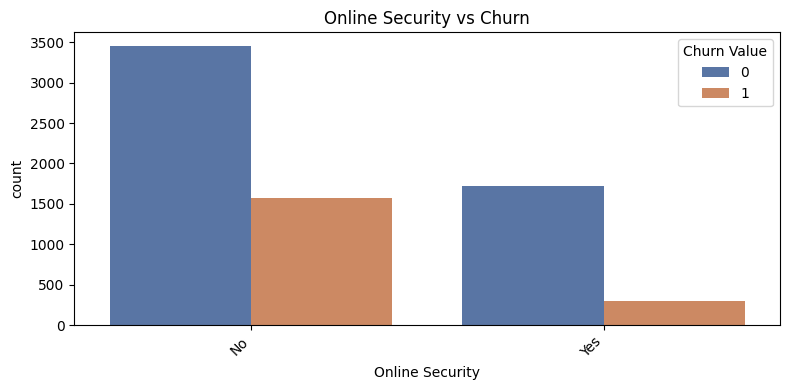

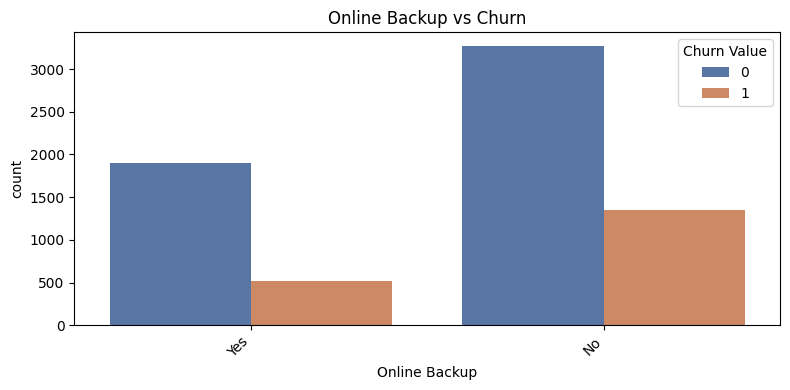

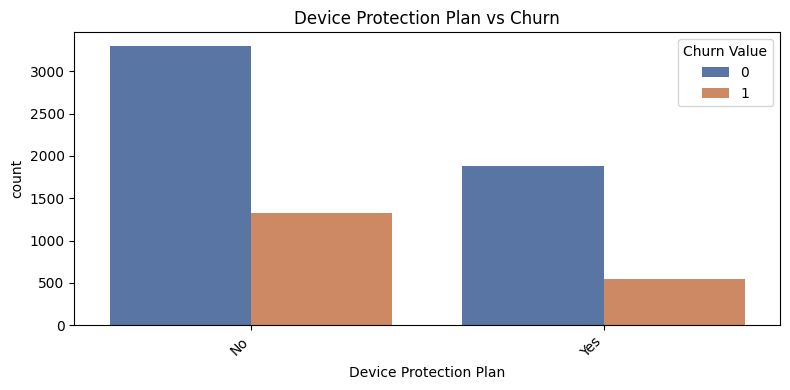

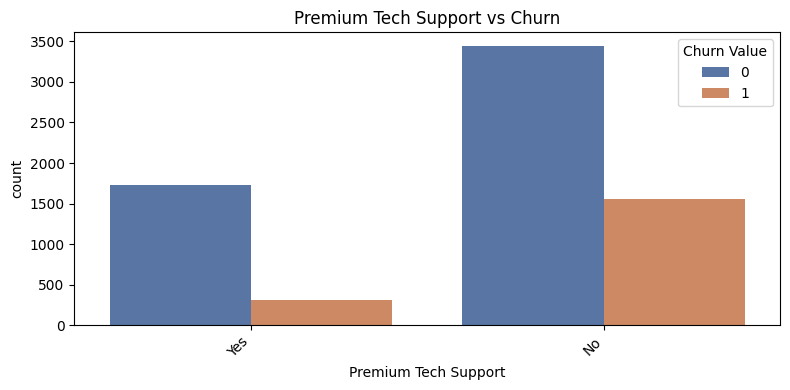

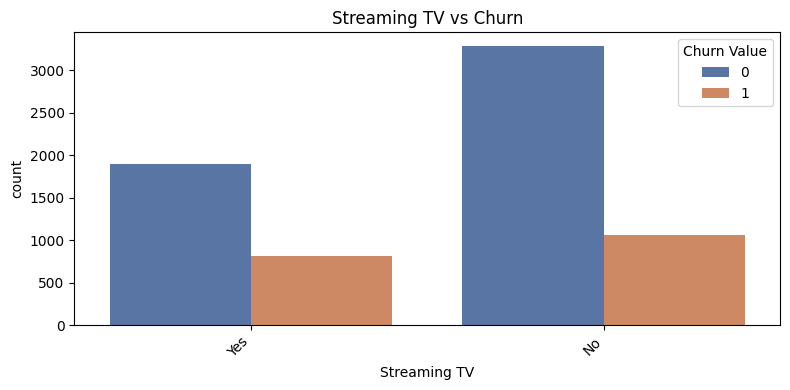

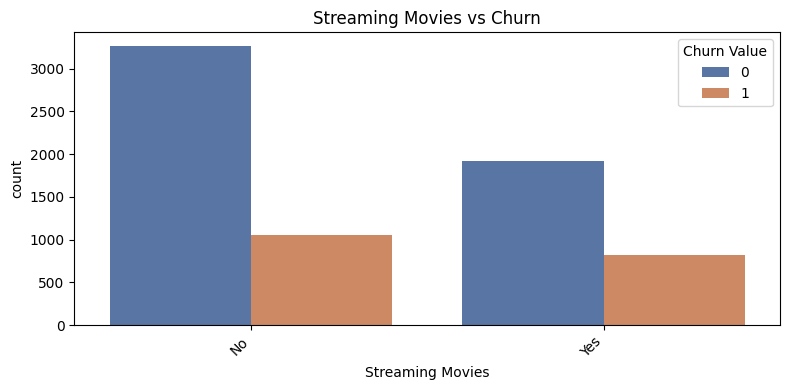

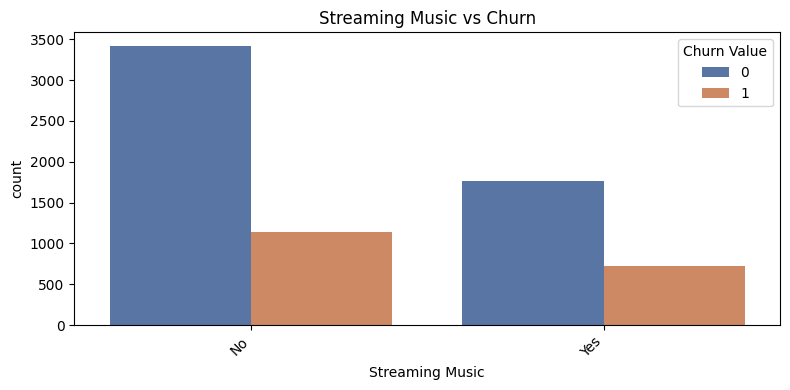

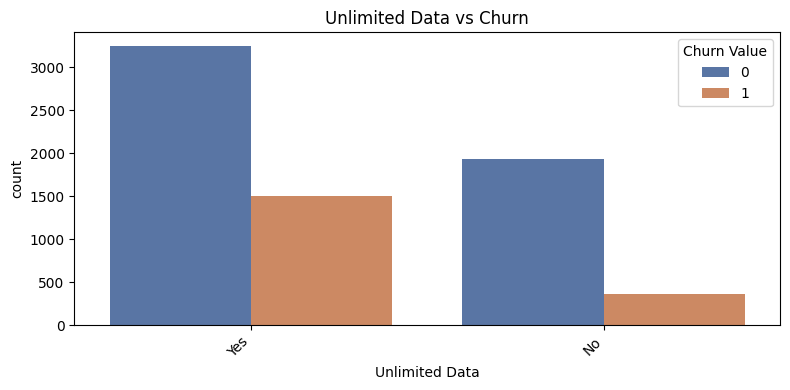

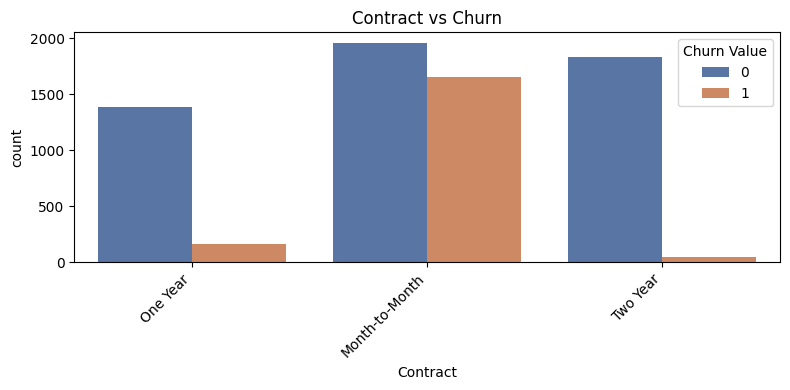

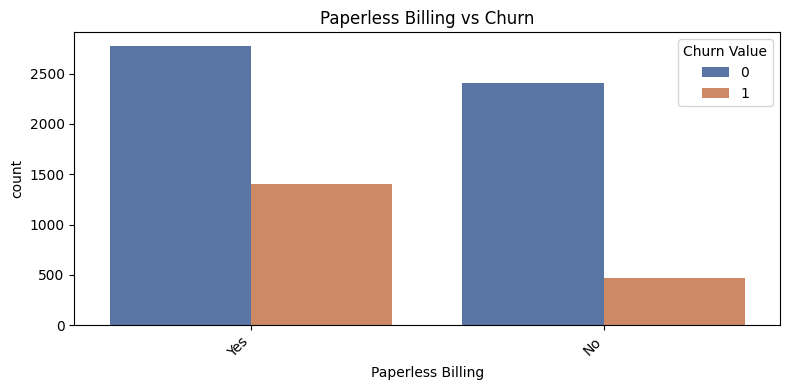

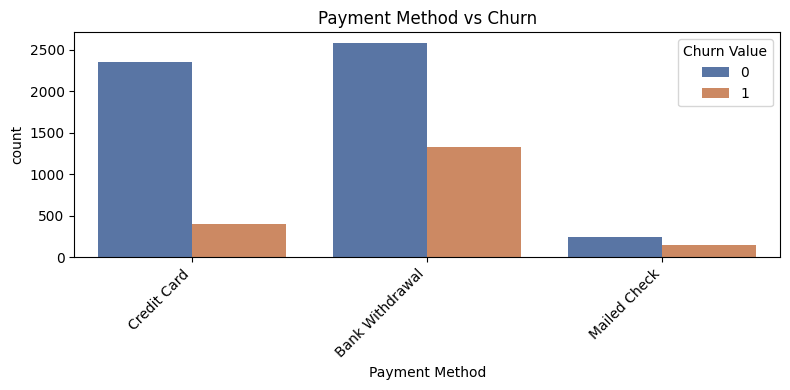

In [10]:
# bar charts of categorical features vs churn
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

cat_cols = [c for c in cat_cols]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Churn Value', palette=['#4C72B0','#DD8452'])
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [11]:
# drop (possible) unimpacted features
df.drop(columns=['Multiple Lines', 'Streaming TV', 'Streaming Movies', 'Streaming Music'], inplace=True)

### Train-test Split

In [12]:
X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

### Pipeline

In [13]:
# define categorical vs numeric columns and encoding methods
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns

cat_cols_le = [col for col in categorical_cols
    if X_train[col].nunique() < 3]

cat_cols_ohe = [col for col in categorical_cols
    if X_train[col].nunique() >= 3]

print("Ordinal Encoding Columns:", cat_cols_le)
print("One-Hot Encoding Columns:", cat_cols_ohe)

Ordinal Encoding Columns: ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Unlimited Data', 'Paperless Billing']
One-Hot Encoding Columns: ['Offer', 'Internet Type', 'Contract', 'Payment Method']


In [14]:
# define transformers for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

le_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder())
])

ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [15]:
# column transformer to apply appropriate transformations to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('le', le_transformer, cat_cols_le),
        ('ohe', ohe_transformer, cat_cols_ohe),
], remainder='passthrough')

### Modelling

In [16]:
# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=rf_cv,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best Random Forest ROC-AUC (CV):", rf_random_search.best_score_)
print("Best Random Forest Parameters:", rf_random_search.best_params_)

best_model = rf_random_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

print(classification_report(y_test, y_pred))

Best Random Forest ROC-AUC (CV): 0.9887298800240562
Best Random Forest Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 20}
Precision: 0.953
Recall: 0.917
F1 Score: 0.935
ROC-AUC: 0.986
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1035
           1       0.95      0.92      0.93       374

    accuracy                           0.97      1409
   macro avg       0.96      0.95      0.96      1409
weighted avg       0.97      0.97      0.97      1409



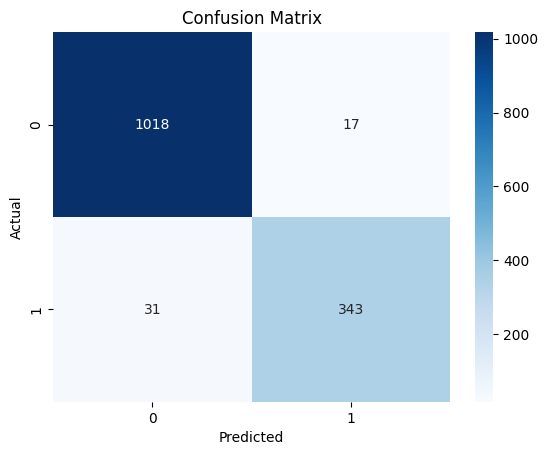

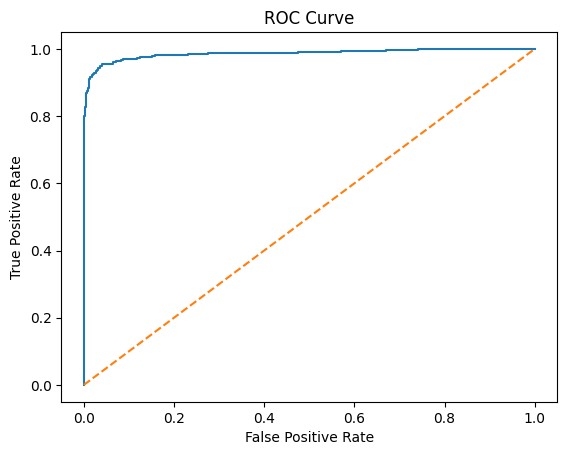

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

c:\Users\tangc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Logistic ROC-AUC (CV): 0.9906791767693791
Best Logistic Parameters: {'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 1}
Precision: 0.873
Recall:    0.936
F1 Score:  0.903
ROC-AUC:   0.992
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1035
           1       0.87      0.94      0.90       374

    accuracy                           0.95      1409
   macro avg       0.92      0.94      0.93      1409
weighted avg       0.95      0.95      0.95      1409



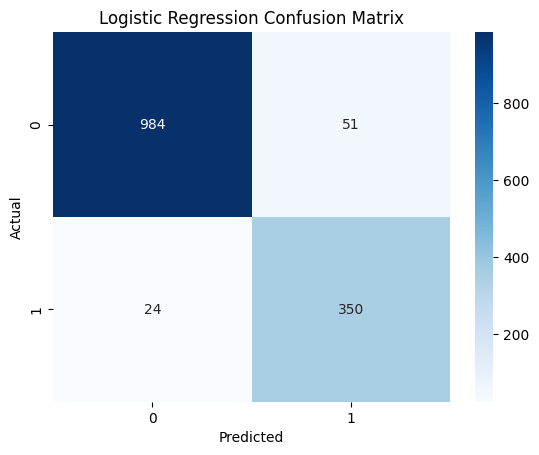

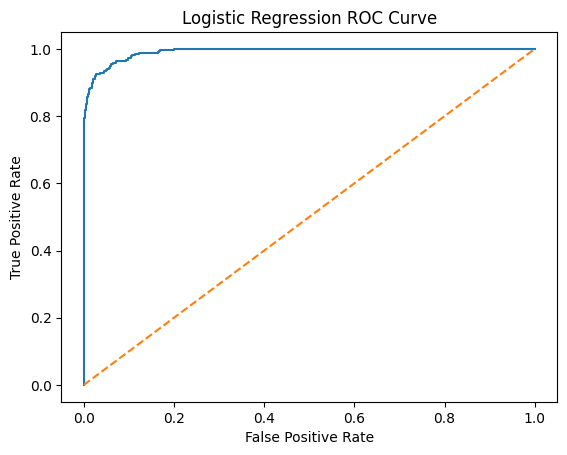

In [18]:
# Logistic Regression pipeline
log_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

log_param_dist = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "saga"]
}

log_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

log_search = RandomizedSearchCV(
    log_pipeline,
    param_distributions=log_param_dist,
    n_iter=10,
    cv=log_cv,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

log_search.fit(X_train, y_train)

print("Best Logistic ROC-AUC (CV):", log_search.best_score_)
print("Best Logistic Parameters:", log_search.best_params_)

best_log = log_search.best_estimator_

y_pred_log = best_log.predict(X_test)
y_prob_log = best_log.predict_proba(X_test)[:, 1]

print(f"Precision: {precision_score(y_test, y_pred_log):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_log):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_log):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_log):.3f}")
print(classification_report(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_l, tpr_l)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.show()

Best KNN ROC-AUC (CV): 0.9722020856644373
Best KNN Parameters: {'model__weights': 'distance', 'model__n_neighbors': 9, 'model__metric': 'euclidean'}
Precision: 0.799
Recall:    0.933
F1 Score:  0.861
ROC-AUC:   0.972
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1035
           1       0.80      0.93      0.86       374

    accuracy                           0.92      1409
   macro avg       0.89      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409



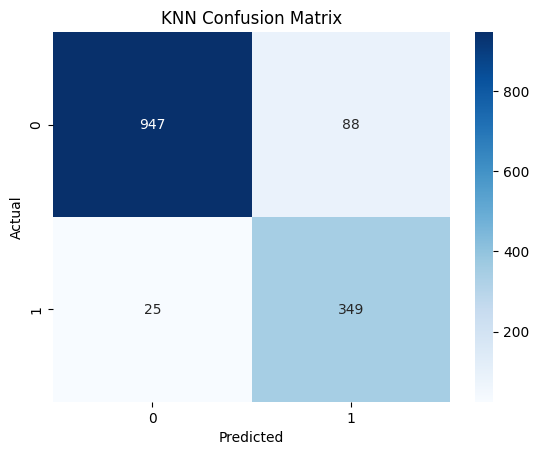

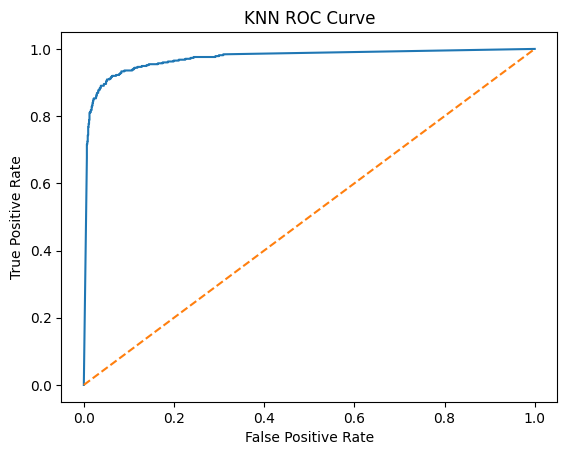

In [19]:
# KNN pipeline
knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", KNeighborsClassifier())
])

knn_param_dist = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=knn_param_dist,
    n_iter=10,
    cv=knn_cv,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

print("Best KNN ROC-AUC (CV):", knn_search.best_score_)
print("Best KNN Parameters:", knn_search.best_params_)

best_knn = knn_search.best_estimator_

y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

print(f"Precision: {precision_score(y_test, y_pred_knn):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_knn):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_knn):.3f}")
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

fpr_k, tpr_k, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr_k, tpr_k)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.show()